# LeetCode #563: Binary Tree Tilt

https://leetcode.com/problems/binary-tree-tilt/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (two passes per node)** | $O(n^2)$ | $O(h)$ |
| **Optimal: DFS Post-order ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (two passes per node)
For each node, compute left subtree sum and right subtree sum with separate DFS calls, then add $|\text{left} - \text{right}|$ to the total tilt. Recomputes subtree sums from scratch for every node: $O(n)$ per node, $O(n^2)$ total.

### Optimal: DFS Post-order ★
Post-order DFS returns the subtree sum for each node. At each node, compute $|\text{leftSum} - \text{rightSum}|$ and accumulate it into a global tilt counter. Return `node.val + leftSum + rightSum` upward. Each node is visited exactly once: $O(n)$ time, $O(h)$ space.

**Why this is better than Brute Force:** Post-order propagation lets each node report its subtree sum once, eliminating the redundant recomputation done in the brute-force approach.

**Constraints:**
* The number of nodes in the tree is in the range $[0, 10^4]$
* $-1000 \le \text{Node.val} \le 1000$


## Solutions

### C#

In [ ]:
public int FindTilt(TreeNode root) {
    int totalTilt = 0;
    int SubtreeSum(TreeNode node) {
        if (node == null) return 0;
        int l = SubtreeSum(node.left), r = SubtreeSum(node.right);
        // Tilt of this node = |left subtree sum - right subtree sum|
        totalTilt += Math.Abs(l - r);
        // Return total sum of this subtree for parent's tilt calculation
        return node.val + l + r;
    }
    SubtreeSum(root);
    return totalTilt;
}

### Python

In [ ]:
def find_tilt(root) -> int:
    total_tilt = 0

    def subtree_sum(node) -> int:
        nonlocal total_tilt
        if not node:
            return 0
        l, r = subtree_sum(node.left), subtree_sum(node.right)
        # Tilt of this node = |left subtree sum - right subtree sum|
        total_tilt += abs(l - r)
        # Return total sum of this subtree for parent's tilt calculation
        return node.val + l + r

    subtree_sum(root)
    return total_tilt

### Go

In [ ]:
func findTilt(root *TreeNode) int {
    totalTilt := 0
    var subtreeSum func(*TreeNode) int
    subtreeSum = func(node *TreeNode) int {
        if node == nil { return 0 }
        l, r := subtreeSum(node.Left), subtreeSum(node.Right)
        // Tilt of this node = |left subtree sum - right subtree sum|
        diff := l - r
        if diff < 0 { diff = -diff }
        totalTilt += diff
        // Return total sum of this subtree for parent's tilt calculation
        return node.Val + l + r
    }
    subtreeSum(root)
    return totalTilt
}

### Rust

In [ ]:
pub fn find_tilt(root: Option<Box<TreeNode>>) -> i32 {
    fn subtree_sum(node: &Option<Box<TreeNode>>, total: &mut i32) -> i32 {
        match node {
            None => 0,
            Some(n) => {
                let l = subtree_sum(&n.left, total);
                let r = subtree_sum(&n.right, total);
                // Tilt of this node = |left subtree sum - right subtree sum|
                *total += (l - r).abs();
                // Return total sum of this subtree for parent's tilt calculation
                n.val + l + r
            }
        }
    }
    let mut total = 0;
    subtree_sum(&root, &mut total);
    total
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [1,2,3]`
Leaf 2: tilt = |0-0| = 0, returns 2. Leaf 3: tilt = 0, returns 3. Root 1: tilt = |2-3| = 1. Total tilt = 0+0+1 = 1.

**2. Slightly Complex**
**Input:** `root = [4,2,9,3,5,null,7]`
Leaf 3: tilt 0, sum 3. Leaf 5: tilt 0, sum 5. Node 2: tilt=|3-5|=2, sum=2+3+5=10. Leaf 7: tilt 0, sum 7. Node 9: tilt=|0-7|=7, sum=9+7=16. Root 4: tilt=|10-16|=6. Total = 0+0+2+0+7+6 = 15.

**3. Edge Case: Time Factor**
**Input:** Right-skewed tree `[1,null,2,null,...,null,n]` ($n = 10^4$)
Every node has only a right child. Post-order visits all $n$ nodes from deepest to root. Each node's tilt is $|0 - \text{rightSum}|$ since left is always null — still $O(n)$ tilt computations.

**4. Edge Case: Space Factor**
**Input:** Perfectly balanced BST of height $h = 14$ ($n \approx 10^4$)
Recursion depth = $h = 14$. Stack holds only 14 frames while processing $10^4$ nodes. Compare with $O(n)$ brute-force storage — the post-order approach is far more space-efficient for balanced trees.

**5. Almost-Impossible but Plausible**
**Input:** `root = [1000, 1000, ..., 1000]` ($10^4$ nodes all with val 1000)
Subtree sums can reach $1000 \times 10^4 = 10^7$, and tilts the absolute differences of such sums. The total tilt accumulator can reach $\approx n \times 10^7 = 10^{11}$ — exceeds 32-bit `int`. Using `long` for `totalTilt` is safer; the problem's constraints guarantee `int` is sufficient with $|\text{Node.val}| \le 1000$ and $n \le 10^4$.


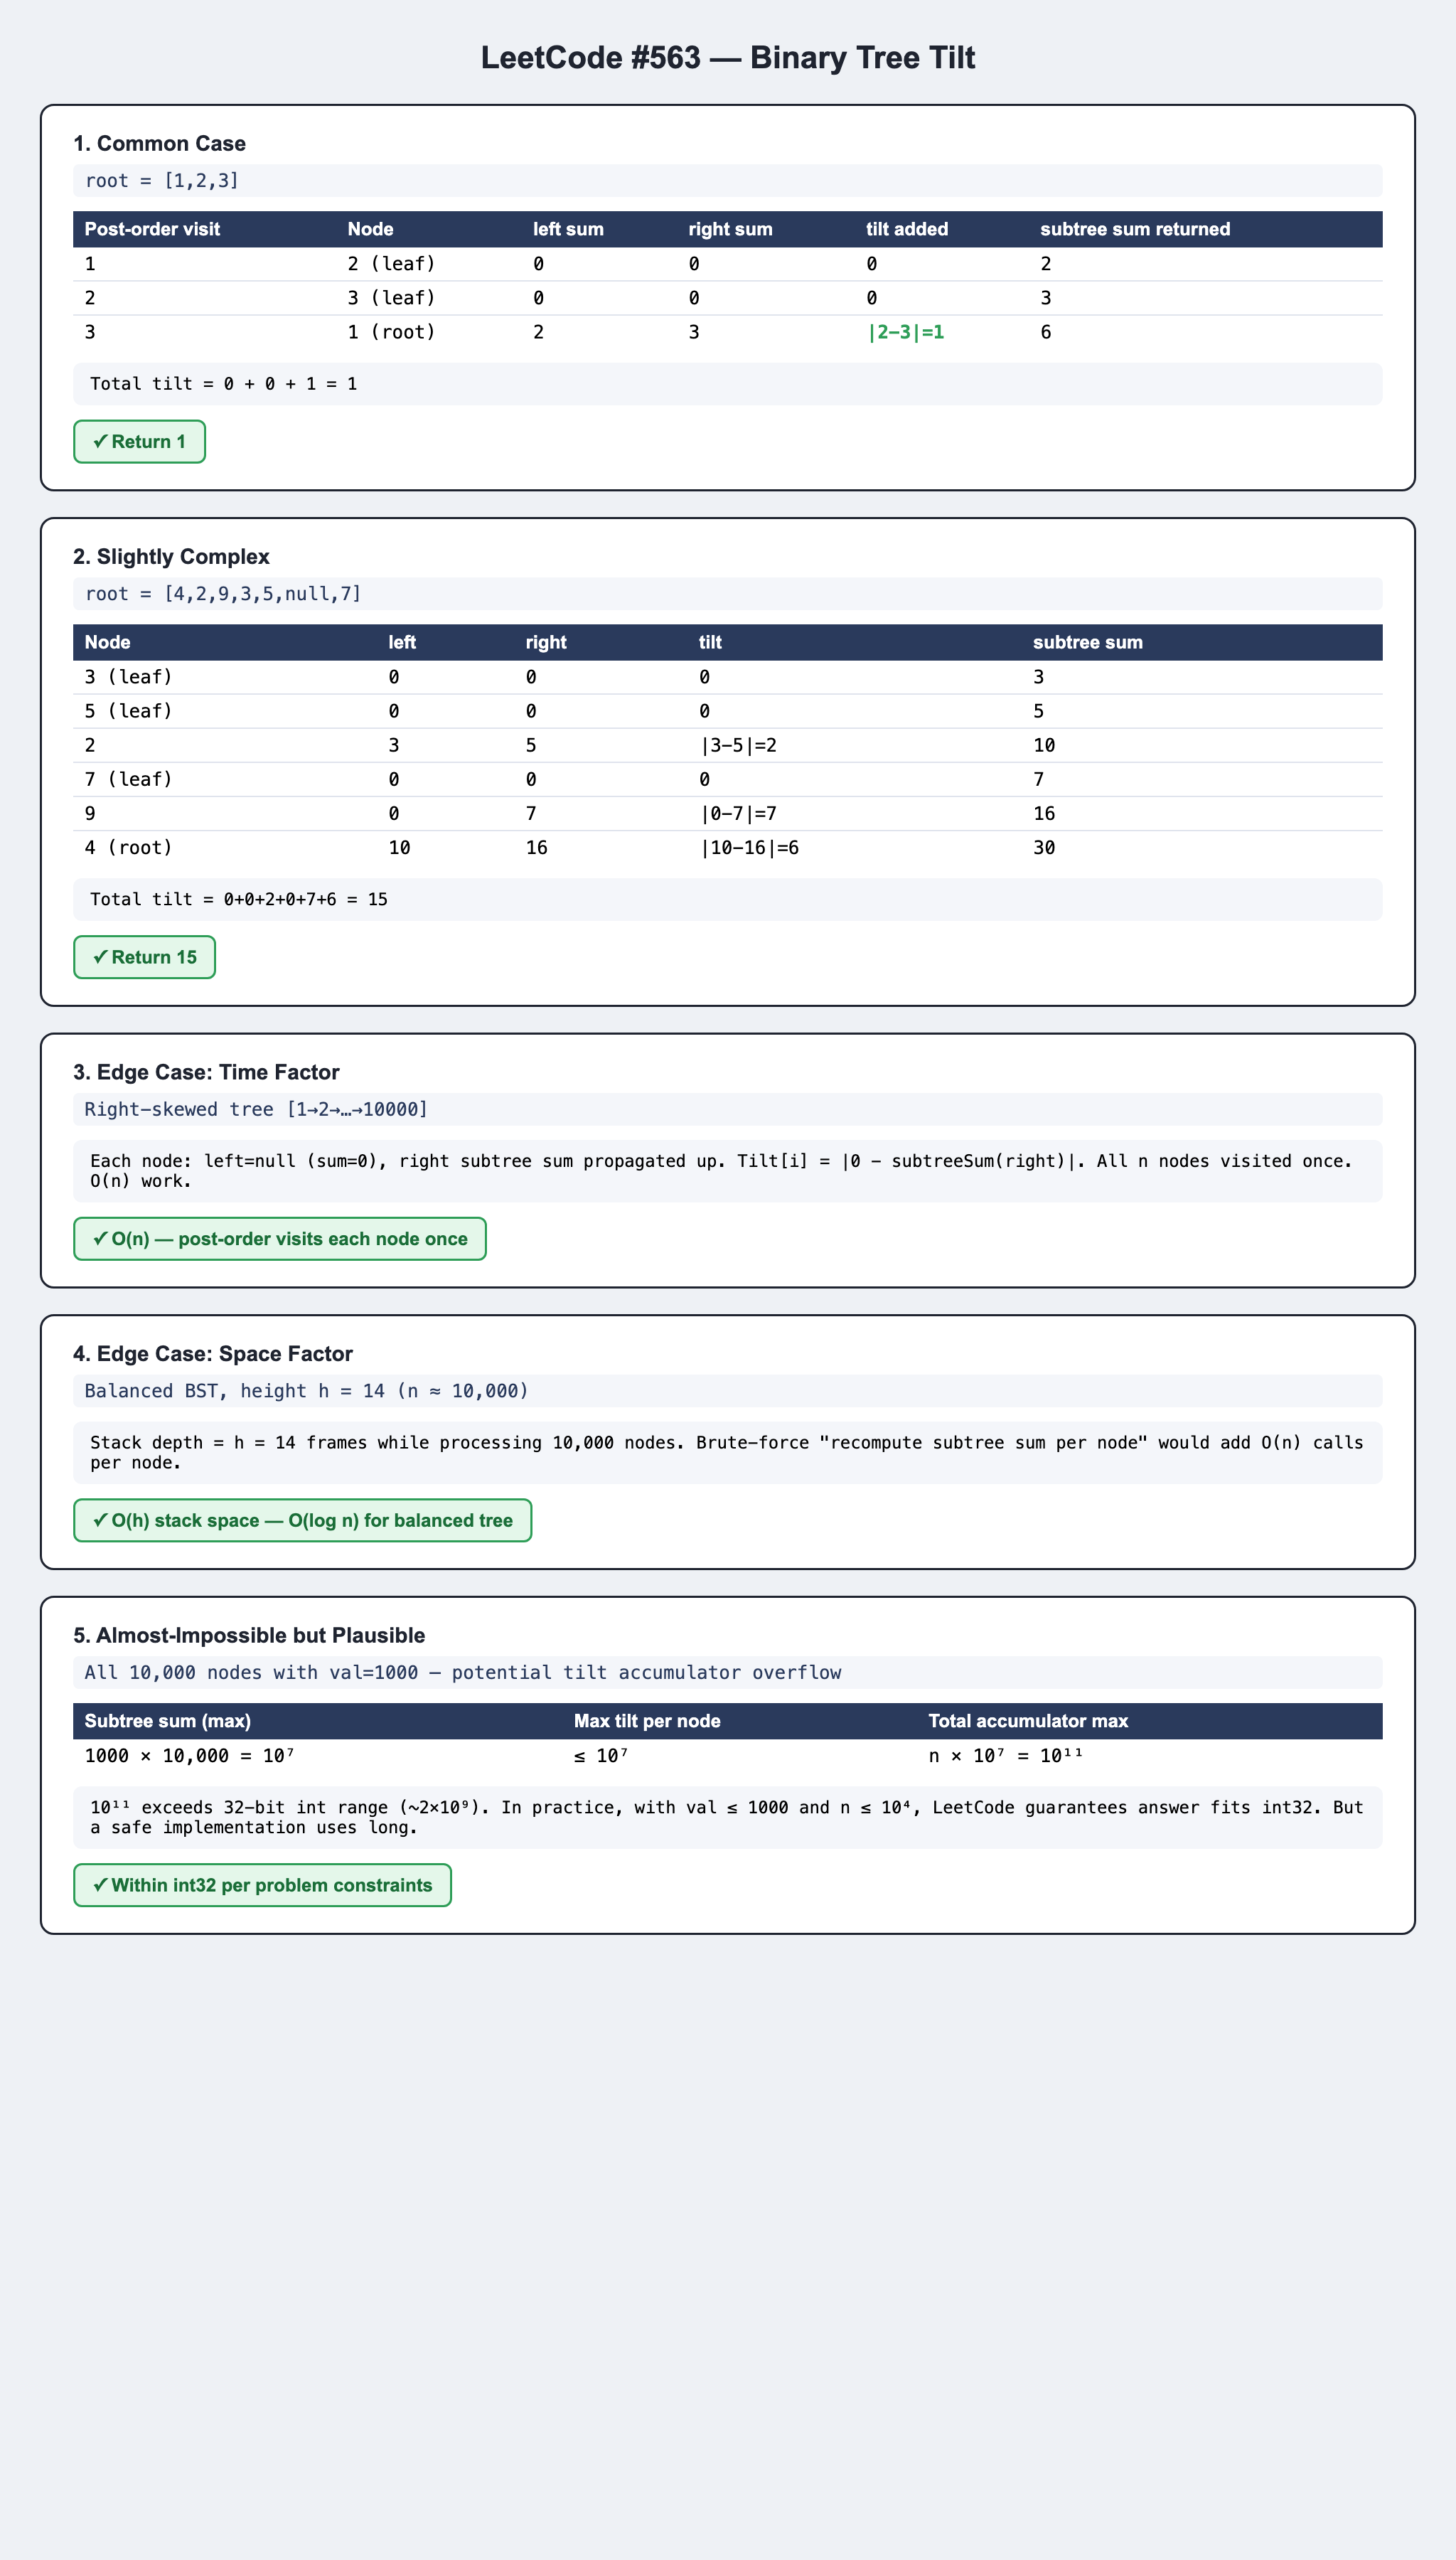